In [1]:
from tensorflow import keras

model = keras.models.load_model("diatom_model.keras")

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

test_dir = r"C:\Users\Yaswanth\Downloads\diatom-classification\dataset\test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 4948 images belonging to 10 classes.


In [3]:
import numpy as np

preds = model.predict(test_ds)
y_pred = np.argmax(preds, axis=1)

y_true = test_ds.classes
class_labels = list(test_ds.class_indices.keys())

155/155 [==============================] - 168s 1s/step


In [4]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

class_accuracy = cm.diagonal() / cm.sum(axis=1)

In [5]:
for i, acc in enumerate(class_accuracy):
    print(f"{class_labels[i]}: {acc:.4f}")

Achnanthidium jackii: 0.6974
Achnanthidium minutissimum: 0.5856
Amphora pediculus: 0.9500
Cocconeis placentula: 0.9836
Discostella pseudostelligera: 0.9773
Navicula gregaria: 0.9204
Navicula lanceolata: 0.9868
Nitzschia dissipata: 0.9392
Nitzschia soratensis: 0.9367
Planothidium lanceolatum: 0.9743


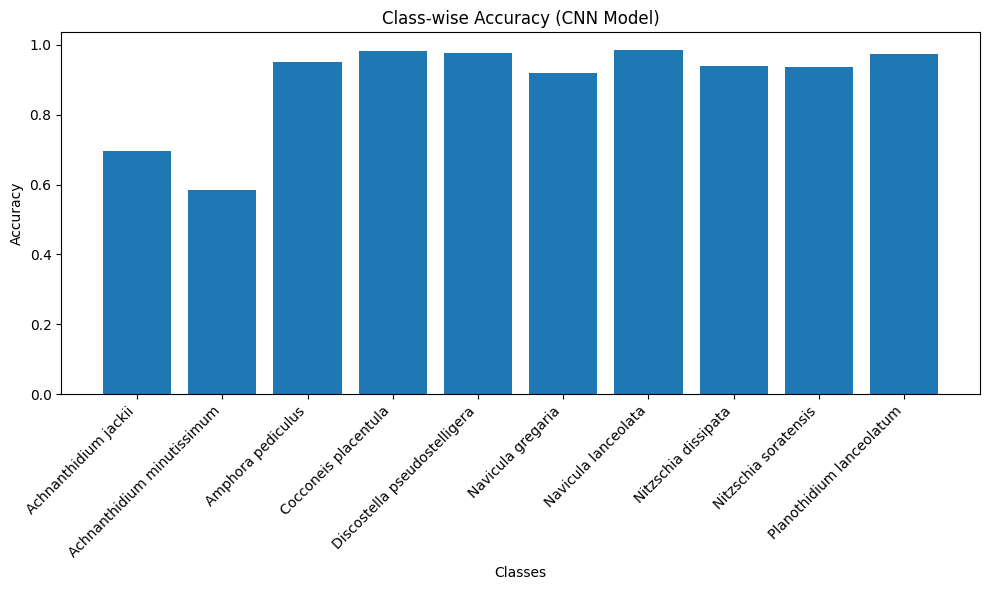

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(class_labels, class_accuracy)
plt.xticks(rotation=45, ha='right')

plt.title("Class-wise Accuracy (CNN Model)")
plt.xlabel("Classes")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

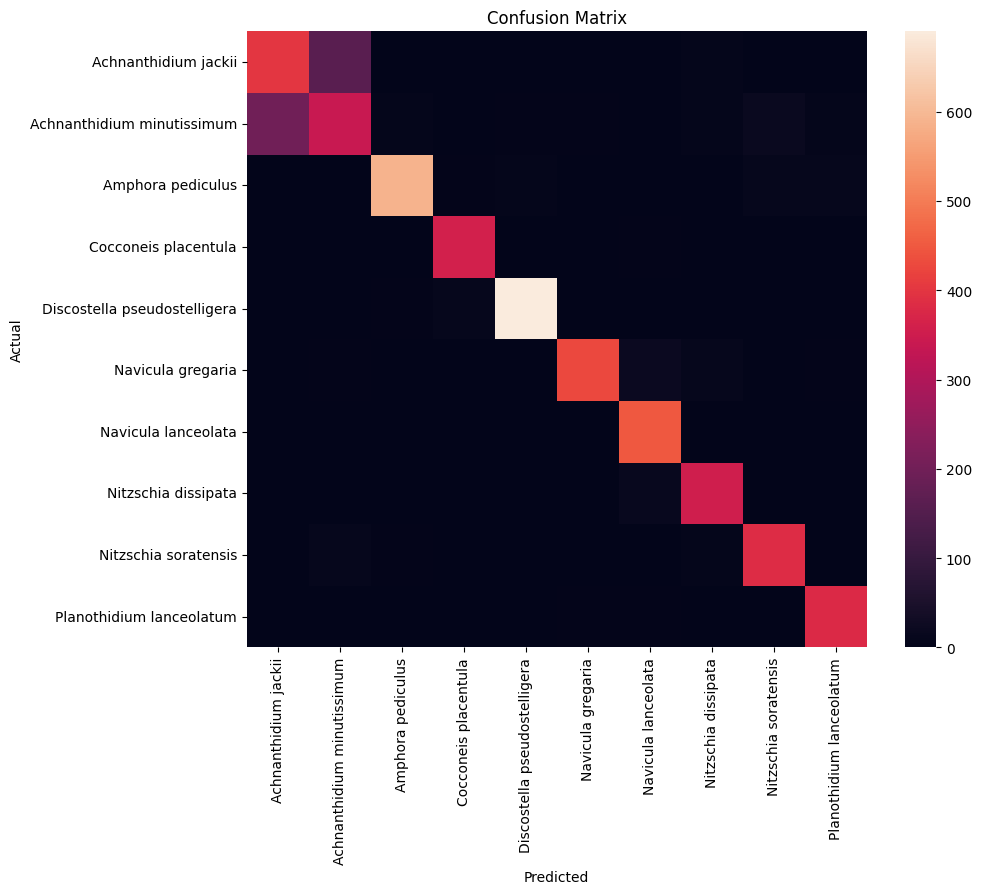

In [7]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=False, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()